# Importar Librerias

In [2]:
import pandas as pd
import numpy as np
import re
import string
import json
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de cómputo: {DEVICE}")

Dispositivo de cómputo: cuda


## Lectura de datos

In [4]:
file_path = 'movie.csv'
df = pd.read_csv(file_path)

## Exploración de datos

En esta sección se carga el dataset (`Train_textosODS.xlsx`), se revisan dimensiones, nombres de columnas (`shape`, `columns`) y la estructura de los datos con `info()` (tipos, nulos). Con `head()` se inspeccionan las primeras filas para comprobar el formato de los textos y la variable objetivo ODS.

### Hallazgos del analisis exploratorio
El conjunto de datos está compuesto por textos asociados a 16 Objetivos de Desarrollo Sostenible (ODS), al analizar la distribución de los textos por clase se observa que los ODS 16, 5 y 4 concentran la mayor cantidad de textos, mientras que los ODS 12, 15 y 9 presentan la menor cantidad de textos, No obstante, el desbalance entre clases es moderado y no representa una diferencia extrema entre el ODS con mayor y menor número de textos, adicional el dataset no contiene textos vacíos ni registros duplicados.

Se observaron las siguientes características:

- Promedio de palabras en el texto son 111 palabras
- El minimo de palabras en un texto fue de 24 palabras
- El maximo de palabras en un texto fue de 268 palabras

Finalmente al analizar el corpus se identificó un vocabulario aproximado de 35000 términos únicos, lo que refleja la alta dimensionalidad de característica de los problemas de procesamiento de lenguaje natural.

In [5]:
# Primeras 5 filas
df.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [6]:
print("Exploración Inicial")
print(f"Shape             : {df.shape}")
print(f"Columnas          : {df.columns.tolist()}")
print(f"Valores nulos     :\n{df.isnull().sum()}")

Exploración Inicial
Shape             : (40000, 2)
Columnas          : ['text', 'label']
Valores nulos     :
text     0
label    0
dtype: int64


In [7]:
print(f"\nDistribución de clases:\n{df['label'].value_counts()}")


Distribución de clases:
label
0    20019
1    19981
Name: count, dtype: int64


In [8]:
print(f"\nEjemplo positivo:\n{df[df['label']==1]['text'].iloc[0][:200]}")
print(f"\nEjemplo negativo:\n{df[df['label']==0]['text'].iloc[0][:200]}")


Ejemplo positivo:
Im a die hard Dads Army fan and nothing will ever change that. I got all the tapes, DVD's and audiobooks and every time i watch/listen to them its brand new. <br /><br />The film. The film is a re run

Ejemplo negativo:
I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" before school, during lunch and after school. We all wanted to be Virgil or Scott. No


In [9]:
# Longitud en caracteres de cada texto (número de caracteres por fila)
df["char_count"]   = df["text"].apply(len)
# Longitud en palabras: split por espacios y cuenta de tokens por texto
df["word_count"]   = df["text"].apply(lambda x: len(x.split()))
# COMENTARIO
df["unique_words"] = df["text"].apply(lambda x: len(set(x.lower().split())))
# COMENTARIO
df["avg_word_len"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
# COMENTARIO
df["sent_label"] = df["label"].map({1: "Positiva", 0: "Negativa"})

In [10]:
print("\n--- Estadísticas descriptivas por clase ---")
print(
    df.groupby("sent_label")[["char_count", "word_count", "unique_words", "avg_word_len"]]
    .describe()
    .T
)


--- Estadísticas descriptivas por clase ---
sent_label              Negativa      Positiva
char_count   count  20019.000000  19981.000000
             mean    1292.536990   1328.083279
             std      942.220087   1032.236721
             min       32.000000     65.000000
             25%      705.000000    690.000000
             50%      973.000000    972.000000
             75%     1571.000000   1621.000000
             max     8969.000000  13704.000000
word_count   count  20019.000000  19981.000000
             mean     229.204606    233.477954
             std      164.326729    177.787207
             min        4.000000     12.000000
             25%      128.000000    125.000000
             50%      174.000000    173.000000
             75%      279.000000    285.000000
             max     1522.000000   2470.000000
unique_words count  20019.000000  19981.000000
             mean     147.970128    148.287873
             std       85.685150     91.743160
             mi

In [11]:
PAL = {"Positiva": "#388697", "Negativa": "#DB162F"}
BG  = "#f8f9fa"

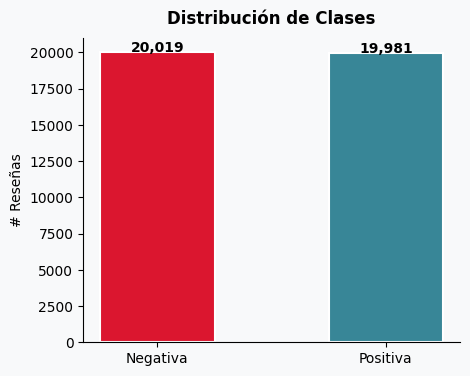

In [12]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # Create an Axes object using the first grid position from gs
vc = df["sent_label"].value_counts()
bars = ax1.bar(
    vc.index, vc.values,
    color=[PAL[k] for k in vc.index],
    width=0.5, edgecolor="white", linewidth=1.5,
)
for b in bars:
    ax1.text(
        b.get_x() + b.get_width() / 2, b.get_height() + 30,
        f"{int(b.get_height()):,}", ha="center", fontweight="bold",
    )
pct = vc / vc.sum() * 100
ax1.set_title("Distribución de Clases", fontweight="bold", pad=10)
ax1.set_ylabel("# Reseñas"); ax1.set_facecolor(BG)
ax1.spines[["top", "right"]].set_visible(False)
plt.show()

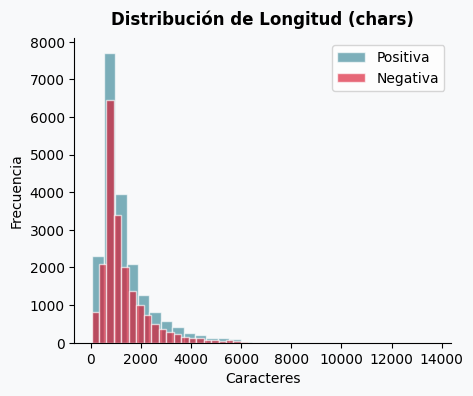

In [13]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax2 = fig.add_subplot(gs[0, 1])
for label, color in PAL.items():
    ax2.hist(
        df[df["sent_label"] == label]["char_count"],
        bins=30, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax2.set_title("Distribución de Longitud (chars)", fontweight="bold", pad=10)
ax2.set_xlabel("Caracteres"); ax2.set_ylabel("Frecuencia")
ax2.legend(); ax2.set_facecolor(BG)
ax2.spines[["top", "right"]].set_visible(False)
plt.show()

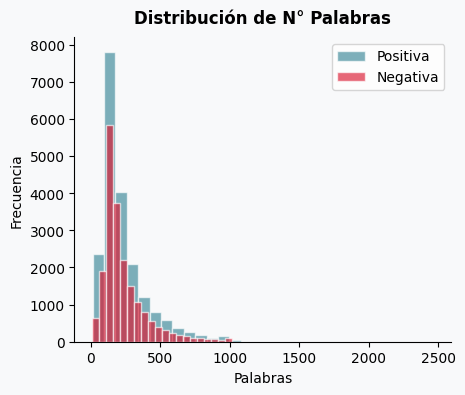

In [14]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax3 = fig.add_subplot(gs[0, 2])
for label, color in PAL.items():
    ax3.hist(
        df[df["sent_label"] == label]["word_count"],
        bins=30, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax3.set_title("Distribución de N° Palabras", fontweight="bold", pad=10)
ax3.set_xlabel("Palabras"); ax3.set_ylabel("Frecuencia")
ax3.legend(); ax3.set_facecolor(BG)
ax3.spines[["top", "right"]].set_visible(False)
plt.show()

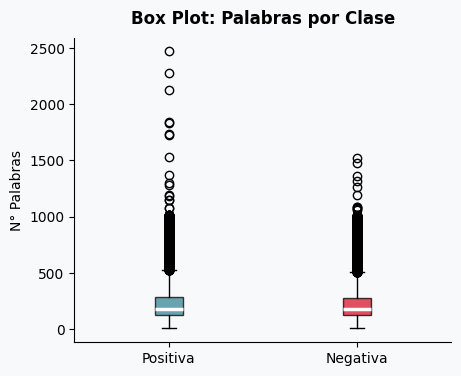

In [15]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax4 = fig.add_subplot(gs[1, 0])
data_box = [df[df["sent_label"] == l]["word_count"].values for l in ["Positiva", "Negativa"]]
bp = ax4.boxplot(
    data_box, labels=["Positiva", "Negativa"], patch_artist=True,
    medianprops=dict(color="white", linewidth=2.5),
)
for patch, color in zip(bp["boxes"], PAL.values()):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax4.set_title("Box Plot: Palabras por Clase", fontweight="bold", pad=10)
ax4.set_ylabel("N° Palabras"); ax4.set_facecolor(BG)
ax4.spines[["top", "right"]].set_visible(False)
plt.show()

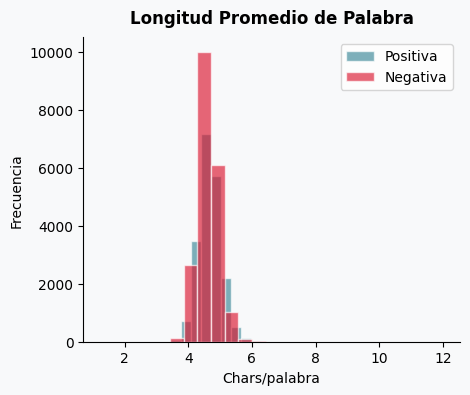

In [16]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax5 = fig.add_subplot(gs[1, 1])
for label, color in PAL.items():
    ax5.hist(
        df[df["sent_label"] == label]["avg_word_len"],
        bins=20, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax5.set_title("Longitud Promedio de Palabra", fontweight="bold", pad=10)
ax5.set_xlabel("Chars/palabra"); ax5.set_ylabel("Frecuencia")
ax5.legend(); ax5.set_facecolor(BG)
ax5.spines[["top", "right"]].set_visible(False)
plt.show()

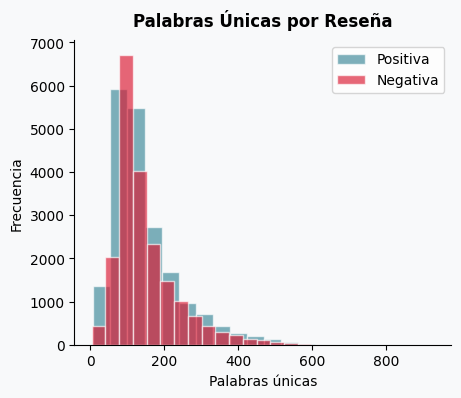

In [17]:
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
ax6 = fig.add_subplot(gs[1, 2])
for label, color in PAL.items():
    ax6.hist(
        df[df["sent_label"] == label]["unique_words"],
        bins=20, alpha=0.65, color=color, label=label, edgecolor="white",
    )
ax6.set_title("Palabras Únicas por Reseña", fontweight="bold", pad=10)
ax6.set_xlabel("Palabras únicas"); ax6.set_ylabel("Frecuencia")
ax6.legend(); ax6.set_facecolor(BG)
ax6.spines[["top", "right"]].set_visible(False)

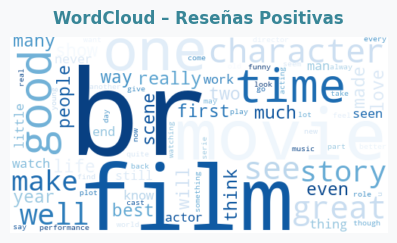

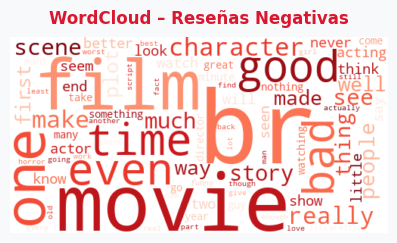

In [18]:
for label, colormap, col in [("Positiva", "Blues", 0), ("Negativa", "Reds", 2)]:
    fig = plt.figure(figsize=(18, 22), facecolor=BG)
    gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.35)
    ax = fig.add_subplot(gs[2, col])
    text = " ".join(df[df["sent_label"] == label]["text"])
    wc = WordCloud(
        width=500, height=260, background_color="white",
        colormap=colormap, max_words=80, collocations=False,
    ).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"WordCloud – Reseñas {label}s", fontweight="bold",
                 pad=10, color=PAL[label])
    plt.show()

## Preparación de los datos

DESCRIPCION DE LO QUE SE HIZO

In [19]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean"] = df["text"].apply(clean_text)

print("\nEjemplo de limpieza:")
print("  Original :", df["text"].iloc[0][:120])
print("  Limpio   :", df["clean"].iloc[0][:120])



Ejemplo de limpieza:
  Original : I grew up (b. 1965) watching and loving the Thunderbirds. All my mates at school watched. We played "Thunderbirds" befor
  Limpio   : i grew up b watching and loving the thunderbirds all my mates at school watched we played thunderbirds before school dur


In [20]:
def tokenize(text: str) -> list[str]:
    """Tokenización por espacios (adecuada tras limpieza previa)."""
    return text.split()


df["tokens"] = df["clean"].apply(tokenize)

In [21]:
STOP_WORDS: set[str] = {
    "a", "an", "the", "and", "or", "but", "in", "on", "at", "to", "for",
    "of", "with", "by", "from", "is", "it", "its", "was", "are", "were",
    "be", "been", "being", "i", "my", "me", "we", "our", "you", "your",
    "he", "she", "they", "this", "that", "what", "which", "who", "have",
    "has", "had", "do", "does", "did", "will", "would", "could", "should",
    "may", "might", "can", "not", "no", "so", "as", "if", "up", "out",
    "about", "just", "like", "more", "also", "very", "too", "much",
    "there", "their", "them", "than", "then", "when", "where", "how",
}

def remove_stopwords(tokens: list[str], stopwords: set[str]) -> list[str]:
    """Filtra tokens que estén en el conjunto de stop words."""
    return [t for t in tokens if t not in stopwords]


df["tokens_clean"] = df["tokens"].apply(lambda t: remove_stopwords(t, STOP_WORDS))

# Comparación visual
print("\nTokenización + Stopwords:")
print("  Tokens raw   :", df["tokens"].iloc[0])
print("  Tokens limpios:", df["tokens_clean"].iloc[0])


Tokenización + Stopwords:
  Tokens raw   : ['i', 'grew', 'up', 'b', 'watching', 'and', 'loving', 'the', 'thunderbirds', 'all', 'my', 'mates', 'at', 'school', 'watched', 'we', 'played', 'thunderbirds', 'before', 'school', 'during', 'lunch', 'and', 'after', 'school', 'we', 'all', 'wanted', 'to', 'be', 'virgil', 'or', 'scott', 'no', 'one', 'wanted', 'to', 'be', 'alan', 'counting', 'down', 'from', 'became', 'an', 'art', 'form', 'i', 'took', 'my', 'children', 'to', 'see', 'the', 'movie', 'hoping', 'they', 'would', 'get', 'a', 'glimpse', 'of', 'what', 'i', 'loved', 'as', 'a', 'child', 'how', 'bitterly', 'disappointing', 'the', 'only', 'high', 'point', 'was', 'the', 'snappy', 'theme', 'tune', 'not', 'that', 'it', 'could', 'compare', 'with', 'the', 'original', 'score', 'of', 'the', 'thunderbirds', 'thankfully', 'early', 'saturday', 'mornings', 'one', 'television', 'channel', 'still', 'plays', 'reruns', 'of', 'the', 'series', 'gerry', 'anderson', 'and', 'his', 'wife', 'created', 'jonatha', 'fr

In [22]:
MIN_FREQ   = 2       # ignorar palabras que aparecen menos de MIN_FREQ veces
VOCAB_SIZE = 10_000  # máximo de tokens en el vocabulario

all_tokens_flat = [tok for toks in df["tokens_clean"] for tok in toks]
vocab_counter   = Counter(all_tokens_flat)

print(f"\nVocabulario total (sin filtro) : {len(vocab_counter):,}")
print(f"Top 10 tokens: {vocab_counter.most_common(10)}")

# Filtrar por frecuencia mínima y tomar top VOCAB_SIZE
vocab_filtered = {
    word for word, count in vocab_counter.items() if count >= MIN_FREQ
}
vocab_sorted = sorted(vocab_filtered, key=lambda w: -vocab_counter[w])[:VOCAB_SIZE]

# Construir mapas word ↔ idx
word2idx: dict[str, int] = {"<PAD>": 0, "<UNK>": 1}
word2idx.update({word: idx + 2 for idx, word in enumerate(vocab_sorted)})
idx2word: dict[int, str] = {v: k for k, v in word2idx.items()}

print(f"Vocabulario filtrado (freq≥{MIN_FREQ}, top {VOCAB_SIZE}) + PAD + UNK : {len(word2idx):,}")


Vocabulario total (sin filtro) : 143,912
Top 10 tokens: [('movie', 68353), ('film', 60685), ('his', 45547), ('one', 41213), ('all', 36587), ('her', 27552), ('some', 24839), ('good', 23259), ('even', 19733), ('time', 19230)]
Vocabulario filtrado (freq≥2, top 10000) + PAD + UNK : 10,002


In [ ]:
# CODIFICACIÓN DE SECUENCIAS + PADDING / TRUNCADO

token_lengths = df["tokens_clean"].apply(len)
print(f"\nLongitudes de secuencia (tokens limpios):")
print(f"  Media  = {token_lengths.mean():.1f}")
print(f"  Mediana= {token_lengths.median():.0f}")
print(f"  P90    = {np.percentile(token_lengths, 90):.0f}")
print(f"  P95    = {np.percentile(token_lengths, 95):.0f}")
print(f"  Max    = {token_lengths.max()}")

MAX_LEN = int(np.percentile(token_lengths, 90))  # cubrir el 90% del corpus
print(f"\nMAX_LEN elegido: {MAX_LEN}  (percentil 90)")


def encode_sequence(tokens: list[str], w2i: dict) -> list[int]:
    """Convierte tokens a índices enteros; usa <UNK>=1 para palabras OOV."""
    return [w2i.get(tok, w2i["<UNK>"]) for tok in tokens]


def pad_or_truncate(seq: list[int], maxlen: int, pad_val: int = 0) -> list[int]:
    """
    Post-truncado (por la derecha) y post-padding.
    Post-padding es el estándar para RNNs con masking posterior.
    """
    seq = seq[:maxlen]                              # truncar si es más larga
    return seq + [pad_val] * (maxlen - len(seq))   # rellenar si es más corta


df["encoded"] = df["tokens_clean"].apply(lambda t: encode_sequence(t, word2idx))
df["padded"]  = df["encoded"].apply(lambda s: pad_or_truncate(s, MAX_LEN))

# Verificación: porcentaje de tokens desconocidos
unk_idx  = word2idx["<UNK>"]
unk_rate = sum((np.array(s) == unk_idx).sum() for s in df["padded"]) / (len(df) * MAX_LEN)
print(f"Tasa de tokens <UNK>: {unk_rate:.2%}  (deseable < 5%)")

# Matrices finales
X = np.array(df["padded"].tolist(), dtype=np.int32)
y = df["label"].values.astype(np.int32)
print(f"\nX shape: {X.shape}  dtype: {X.dtype}")
print(f"y shape: {y.shape}  dtype: {y.dtype}")


Longitudes de secuencia (tokens limpios):
  Media  = 127.4
  Mediana= 94
  P90    = 252
  P95    = 331
  Max    = 1584

MAX_LEN elegido: 252  (percentil 90)
Tasa de tokens <UNK>: 5.09%  (deseable < 5%)

X shape: (40000, 252)  dtype: int32
y shape: (40000,)  dtype: int32


: 

In [ ]:
# #DIVISION SET DE DATOS

# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y, test_size=0.20, random_state=42, stratify=y
# )
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
# )

# print(f"\nDivisión del dataset:")
# print(f"  Train : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)"
#       f"  | Positivos: {y_train.mean():.1%}")
# print(f"  Val   : {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.0f}%)"
#       f"  | Positivos: {y_val.mean():.1%}")
# print(f"  Test  : {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)"
#       f"  | Positivos: {y_test.mean():.1%}")


División del dataset:
  Train : 32,000 (80%)  | Positivos: 50.0%
  Val   : 4,000 (10%)  | Positivos: 50.0%
  Test  : 4,000 (10%)  | Positivos: 50.0%


: 

In [ ]:
SAMPLE_FRAC = 0.20   # ← ajusta si quieres más/menos datos

df_sample = (
    df.groupby("label", group_keys=False)
      .apply(lambda g: g.sample(frac=SAMPLE_FRAC, random_state=SEED))
      .reset_index(drop=True)
)
print(f"Dataset reducido: {len(df_sample):,} reseñas  "
      f"(positivas: {df_sample['label'].mean():.1%})")

X_s = np.array(df_sample["padded"].tolist(), dtype=np.int32)
y_s = df_sample["label"].values.astype(np.int32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_s, y_s, test_size=0.20, random_state=SEED, stratify=y_s
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"  Train : {len(X_train):,}  | Val: {len(X_val):,}  | Test: {len(X_test):,}")


Dataset reducido: 8,000 reseñas  (positivas: 50.0%)
  Train : 6,400  | Val: 800  | Test: 800


: 

### CONSTRUCCIÓN DEL MODELO RNN

In [ ]:
# PyTorch requiere encapsular los datos en un objeto Dataset para que el
# DataLoader pueda crear mini-batches de forma eficiente y aleatoria.

class IMDbDataset(Dataset):
    """
    Dataset personalizado para reseñas IMDb.

    Convierte arrays NumPy a tensores PyTorch en __getitem__ (lazy),
    lo que evita cargar todo en memoria GPU de golpe.
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        # long() para índices de embedding; float() para BCE loss
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def build_dataloaders(train_data, val_data, test_data, batch_size: int = 64):
    """
    Construye DataLoaders para train, val y test.

    batch_size=64: balance entre velocidad de convergencia y uso de memoria.
    shuffle=True en train para romper correlaciones entre batches.
    """
    print(f"\n[2] Construyendo DataLoaders (batch_size={batch_size})...")

    train_ds = IMDbDataset(*train_data)
    val_ds   = IMDbDataset(*val_data)
    test_ds  = IMDbDataset(*test_data)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

: 

In [ ]:
# # PyTorch requiere encapsular los datos en un objeto Dataset para que el
# # DataLoader pueda crear mini-batches de forma eficiente y aleatoria.

# class IMDbDataset(Dataset):
#     """
#     Dataset personalizado para reseñas IMDb.

#     Convierte arrays NumPy a tensores PyTorch en __getitem__ (lazy),
#     lo que evita cargar todo en memoria GPU de golpe.
#     """
#     def __init__(self, X: np.ndarray, y: np.ndarray):
#         # long() para índices de embedding; float() para BCE loss
#         self.X = torch.tensor(X, dtype=torch.long)
#         self.y = torch.tensor(y, dtype=torch.float32)

#     def __len__(self):
#         return len(self.X)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]


# def build_dataloaders(train_data, val_data, test_data, batch_size: int = 64):
#     """
#     Construye DataLoaders para train, val y test.

#     batch_size=64: balance entre velocidad de convergencia y uso de memoria.
#     shuffle=True en train para romper correlaciones entre batches.
#     """
#     print(f"\n[2] Construyendo DataLoaders (batch_size={batch_size})...")

#     train_ds = IMDbDataset(*train_data)
#     val_ds   = IMDbDataset(*val_data)
#     test_ds  = IMDbDataset(*test_data)

#     train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
#     val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
#     test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

#     return train_loader, val_loader, test_loader

: 

In [ ]:

# class SentimentLSTM(nn.Module):
#     """
#     Arquitectura: Embedding → LSTM → Dropout → Linear → Sigmoid

#     Capas y justificación:
#     ──────────────────────
#     1. Embedding(vocab_size, embed_dim):
#        Representa cada token como un vector denso de `embed_dim` dimensiones,
#        aprendido durante el entrenamiento (embeddings contextuales al dataset).
#        Alternativa: cargar pesos pre-entrenados (GloVe/Word2Vec).

#     2. LSTM(embed_dim, hidden_dim, num_layers, bidirectional):
#        Captura dependencias de largo plazo en la secuencia. El parámetro
#        `bidirectional` permite conmutar entre LSTM y BiLSTM sin duplicar código.
#        Con BiLSTM, el estado oculto final tiene tamaño hidden_dim * 2, ya que
#        concatena las representaciones forward y backward.

#     3. Dropout(dropout_rate):
#        Regularización: desactiva neuronas aleatoriamente durante el
#        entrenamiento para reducir el sobreajuste (overfitting).

#     4. Linear → Sigmoid:
#        Proyecta el estado oculto final a un escalar en (0, 1), interpretado
#        como P(reseña positiva). Se usa BCE (Binary Cross-Entropy) como loss.
#     """

#     def __init__(self,
#                  vocab_size: int,
#                  embed_dim: int   = 128,
#                  hidden_dim: int  = 256,
#                  num_layers: int  = 2,
#                  dropout: float   = 0.3,
#                  bidirectional: bool = False):

#         super().__init__()

#         self.bidirectional = bidirectional
#         self.hidden_dim    = hidden_dim
#         self.num_layers    = num_layers

#         # padding_idx=0: el token <PAD> no contribuye al gradiente
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

#         self.lstm = nn.LSTM(
#             input_size    = embed_dim,
#             hidden_size   = hidden_dim,
#             num_layers    = num_layers,
#             batch_first   = True,       # entrada: (batch, seq, features)
#             dropout       = dropout if num_layers > 1 else 0.0,
#             bidirectional = bidirectional
#         )

#         # Si es bidireccional, la representación final es hidden_dim * 2
#         lstm_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

#         self.dropout = nn.Dropout(dropout)
#         self.fc      = nn.Linear(lstm_out_dim, 1)
#         self.sigmoid = nn.Sigmoid()

#     def forward(self, x):
#         # x: (batch, seq_len)  → enteros (índices de vocabulario)
#         emb = self.embedding(x)            # (batch, seq_len, embed_dim)

#         # output: (batch, seq_len, hidden*dirs)
#         # hidden: (num_layers*dirs, batch, hidden_dim)
#         output, (hidden, _) = self.lstm(emb)

#         if self.bidirectional:
#             # Concatenamos el último estado de la dirección forward (capa final)
#             # y el último estado de la dirección backward (capa final)
#             # hidden[-2]: forward último layer | hidden[-1]: backward último layer
#             h = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden*2)
#         else:
#             h = hidden[-1]   # (batch, hidden_dim) — último layer, último timestep

#         h   = self.dropout(h)
#         out = self.fc(h)          # (batch, 1)
#         out = self.sigmoid(out)   # (batch, 1) ∈ (0, 1)
#         return out.squeeze(1)     # (batch,)


: 

In [ ]:

class SentimentLSTM(nn.Module):
    """
    Arquitectura: Embedding → LSTM → Dropout → Linear → Sigmoid

    Capas y justificación:
    ──────────────────────
    1. Embedding(vocab_size, embed_dim):
       Representa cada token como un vector denso de `embed_dim` dimensiones,
       aprendido durante el entrenamiento (embeddings contextuales al dataset).
       Alternativa: cargar pesos pre-entrenados (GloVe/Word2Vec).

    2. LSTM(embed_dim, hidden_dim, num_layers, bidirectional):
       Captura dependencias de largo plazo en la secuencia. El parámetro
       `bidirectional` permite conmutar entre LSTM y BiLSTM sin duplicar código.
       Con BiLSTM, el estado oculto final tiene tamaño hidden_dim * 2, ya que
       concatena las representaciones forward y backward.

    3. Dropout(dropout_rate):
       Regularización: desactiva neuronas aleatoriamente durante el
       entrenamiento para reducir el sobreajuste (overfitting).

    4. Linear → Sigmoid:
       Proyecta el estado oculto final a un escalar en (0, 1), interpretado
       como P(reseña positiva). Se usa BCE (Binary Cross-Entropy) como loss.
    """

    def __init__(self,
                 vocab_size: int,
                 embed_dim: int   = 128,
                 hidden_dim: int  = 256,
                 num_layers: int  = 2,
                 dropout: float   = 0.3,
                 bidirectional: bool = False):

        super().__init__()

        self.bidirectional = bidirectional
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers

        # padding_idx=0: el token <PAD> no contribuye al gradiente
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,       # entrada: (batch, seq, features)
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = bidirectional
        )

        # Si es bidireccional, la representación final es hidden_dim * 2
        lstm_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(lstm_out_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len)  → enteros (índices de vocabulario)
        emb = self.embedding(x)            # (batch, seq_len, embed_dim)

        # output: (batch, seq_len, hidden*dirs)
        # hidden: (num_layers*dirs, batch, hidden_dim)
        output, (hidden, _) = self.lstm(emb)

        if self.bidirectional:
            # Concatenamos el último estado de la dirección forward (capa final)
            # y el último estado de la dirección backward (capa final)
            # hidden[-2]: forward último layer | hidden[-1]: backward último layer
            h = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (batch, hidden*2)
        else:
            h = hidden[-1]   # (batch, hidden_dim) — último layer, último timestep

        h   = self.dropout(h)
        out = self.fc(h)          # (batch, 1)
        out = self.sigmoid(out)   # (batch, 1) ∈ (0, 1)
        return out.squeeze(1)     # (batch,)


: 

In [ ]:

def train_epoch(model, loader, optimizer, criterion):
    """Ejecuta una época de entrenamiento. Retorna loss y accuracy promedio."""
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        optimizer.zero_grad()           # Limpia gradientes del batch anterior
        preds = model(X_batch)          # Forward pass
        loss  = criterion(preds, y_batch)
        loss.backward()                 # Backpropagation

        # Gradient clipping: evita explosión de gradientes (problema clásico en RNN)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()               # Actualiza pesos

        total_loss    += loss.item() * len(y_batch)
        total_correct += ((preds >= 0.5).float() == y_batch).sum().item()
        total         += len(y_batch)

    return total_loss / total, total_correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    """Evaluación sin gradientes. Retorna loss, accuracy y predicciones."""
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        preds = model(X_batch)
        loss  = criterion(preds, y_batch)

        total_loss    += loss.item() * len(y_batch)
        binary_preds   = (preds >= 0.5).float()
        total_correct += (binary_preds == y_batch).sum().item()
        total         += len(y_batch)

        all_preds.extend(binary_preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    return total_loss / total, total_correct / total, all_preds, all_labels


def train_model(model, train_loader, val_loader,
                n_epochs: int = 20,
                lr: float = 1e-3,
                patience: int = 4):
    """
    Loop de entrenamiento completo con early stopping.

    Early stopping: si la val_loss no mejora en `patience` épocas consecutivas,
    se interrumpe el entrenamiento para evitar overfitting y se restaura el
    mejor modelo visto hasta ese punto.

    Hiperparámetros:
      lr=1e-3  : Adam es robusto a esta tasa de aprendizaje inicial.
      patience=4: permite cierta fluctuación de val_loss sin parar prematuramente.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()   # Binary Cross-Entropy para clasificación binaria

    # Scheduler: reduce lr si val_loss no mejora en 2 épocas
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss  = float("inf")
    best_state     = None
    epochs_no_improve = 0

    print(f"\n{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
          f"{'Train Acc':>10} | {'Val Acc':>10}")
    print("-" * 60)

    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
              f"{train_acc:>10.4f} | {val_acc:>10.4f}")

        # Early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\n   Early stopping en época {epoch}. "
                      f"Mejor val_loss: {best_val_loss:.4f}")
                break

    # Restaurar el mejor estado del modelo
    model.load_state_dict(best_state)
    return history

: 

In [ ]:

# def train_epoch(model, loader, optimizer, criterion):
#     """Ejecuta una época de entrenamiento. Retorna loss y accuracy promedio."""
#     model.train()
#     total_loss, total_correct, total = 0.0, 0, 0

#     for X_batch, y_batch in loader:
#         X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

#         optimizer.zero_grad()           # Limpia gradientes del batch anterior
#         preds = model(X_batch)          # Forward pass
#         loss  = criterion(preds, y_batch)
#         loss.backward()                 # Backpropagation

#         # Gradient clipping: evita explosión de gradientes (problema clásico en RNN)
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

#         optimizer.step()               # Actualiza pesos

#         total_loss    += loss.item() * len(y_batch)
#         total_correct += ((preds >= 0.5).float() == y_batch).sum().item()
#         total         += len(y_batch)

#     return total_loss / total, total_correct / total


# @torch.no_grad()
# def evaluate(model, loader, criterion):
#     """Evaluación sin gradientes. Retorna loss, accuracy y predicciones."""
#     model.eval()
#     total_loss, total_correct, total = 0.0, 0, 0
#     all_preds, all_labels = [], []

#     for X_batch, y_batch in loader:
#         X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

#         preds = model(X_batch)
#         loss  = criterion(preds, y_batch)

#         total_loss    += loss.item() * len(y_batch)
#         binary_preds   = (preds >= 0.5).float()
#         total_correct += (binary_preds == y_batch).sum().item()
#         total         += len(y_batch)

#         all_preds.extend(binary_preds.cpu().numpy())
#         all_labels.extend(y_batch.cpu().numpy())

#     return total_loss / total, total_correct / total, all_preds, all_labels


# def train_model(model, train_loader, val_loader,
#                 n_epochs: int = 20,
#                 lr: float = 1e-3,
#                 patience: int = 4):
#     """
#     Loop de entrenamiento completo con early stopping.

#     Early stopping: si la val_loss no mejora en `patience` épocas consecutivas,
#     se interrumpe el entrenamiento para evitar overfitting y se restaura el
#     mejor modelo visto hasta ese punto.

#     Hiperparámetros:
#       lr=1e-3  : Adam es robusto a esta tasa de aprendizaje inicial.
#       patience=4: permite cierta fluctuación de val_loss sin parar prematuramente.
#     """
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     criterion = nn.BCELoss()   # Binary Cross-Entropy para clasificación binaria

#     # Scheduler: reduce lr si val_loss no mejora en 2 épocas
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)

#     history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
#     best_val_loss  = float("inf")
#     best_state     = None
#     epochs_no_improve = 0

#     print(f"\n{'Época':>6} | {'Train Loss':>10} | {'Val Loss':>10} | "
#           f"{'Train Acc':>10} | {'Val Acc':>10}")
#     print("-" * 60)

#     for epoch in range(1, n_epochs + 1):
#         train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
#         val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)

#         scheduler.step(val_loss)

#         history["train_loss"].append(train_loss)
#         history["val_loss"].append(val_loss)
#         history["train_acc"].append(train_acc)
#         history["val_acc"].append(val_acc)

#         print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | "
#               f"{train_acc:>10.4f} | {val_acc:>10.4f}")

#         # Early stopping
#         if val_loss < best_val_loss - 1e-4:
#             best_val_loss = val_loss
#             best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#             epochs_no_improve = 0
#         else:
#             epochs_no_improve += 1
#             if epochs_no_improve >= patience:
#                 print(f"\n   Early stopping en época {epoch}. "
#                       f"Mejor val_loss: {best_val_loss:.4f}")
#                 break

#     # Restaurar el mejor estado del modelo
#     model.load_state_dict(best_state)
#     return history

: 

In [ ]:

def plot_training_curves(hist_lstm, hist_bilstm, save_path="curvas_entrenamiento.png"):
    """
    Grafica las curvas de loss y accuracy para ambos modelos en subplots.
    Formato compatible con reporte IEEE (figura autocontenida con caption).
    """
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle("Curvas de Entrenamiento: LSTM vs BiLSTM", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

    models  = [("LSTM Unidireccional", hist_lstm), ("BiLSTM", hist_bilstm)]
    metrics = [("Loss", "train_loss", "val_loss"), ("Accuracy", "train_acc", "val_acc")]

    for col, (model_name, hist) in enumerate(models):
        for row, (metric_name, train_key, val_key) in enumerate(metrics):
            ax = fig.add_subplot(gs[row, col])
            epochs = range(1, len(hist[train_key]) + 1)
            ax.plot(epochs, hist[train_key], "o-", label="Train", color="#2196F3", linewidth=1.8)
            ax.plot(epochs, hist[val_key],   "s--", label="Val",   color="#FF5722", linewidth=1.8)
            ax.set_title(f"{model_name} — {metric_name}", fontsize=11)
            ax.set_xlabel("Época")
            ax.set_ylabel(metric_name)
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"\n   Curvas guardadas en: {save_path}")


def plot_comparison(results: dict, save_path="comparacion_modelos.png"):
    """
    Gráfico de barras comparando las métricas finales de ambos modelos en test.
    """
    metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
    x       = np.arange(len(metrics))
    width   = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars1 = ax.bar(x - width/2, [results["LSTM"][m]   for m in metrics],
                   width, label="LSTM", color="#2196F3", alpha=0.85)
    bars2 = ax.bar(x + width/2, [results["BiLSTM"][m] for m in metrics],
                   width, label="BiLSTM", color="#FF5722", alpha=0.85)

    ax.set_ylim(0, 1.12)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylabel("Valor", fontsize=11)
    ax.set_title("Comparación de Métricas en Conjunto de Prueba", fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3)

    # Etiquetas sobre cada barra
    for bar in list(bars1) + list(bars2):
        ax.annotate(f"{bar.get_height():.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"   Comparación guardada en: {save_path}")


: 

In [ ]:

def compute_metrics(all_preds, all_labels):
    """Calcula accuracy, precision, recall y F1 en test."""
    return {
        "Accuracy" : accuracy_score(all_labels, all_preds),
        "Precision": precision_score(all_labels, all_preds, zero_division=0),
        "Recall"   : recall_score(all_labels, all_preds, zero_division=0),
        "F1-Score" : f1_score(all_labels, all_preds, zero_division=0),
    }


def run_experiment(model_name: str, vocab_size: int,
                   train_loader, val_loader, test_loader,
                   bidirectional: bool = False):
    """
    Entrena y evalúa un modelo (LSTM o BiLSTM). Retorna history y métricas.

    Hiperparámetros del modelo:
      embed_dim=128  : dimensión del espacio de embedding. Suficiente para vocabulario
                       de tamaño medio; valores más grandes (300) son útiles con GloVe.
      hidden_dim=256 : unidades en la capa LSTM. Equilibrio entre capacidad y costo.
      num_layers=2   : dos capas LSTM apiladas permiten representaciones más abstractas.
      dropout=0.3    : regularización moderada; evita overfitting sin sacrificar capacidad.
    """
    print(f"\n{'='*60}")
    print(f"  Entrenando: {model_name}")
    print(f"{'='*60}")

    model = SentimentLSTM(
        vocab_size    = vocab_size,
        embed_dim     = 128,
        hidden_dim    = 256,
        num_layers    = 2,
        dropout       = 0.3,
        bidirectional = bidirectional
    ).to(DEVICE)

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Parámetros entrenables: {n_params:,}")
    print(model)

    history = train_model(model, train_loader, val_loader,
                          n_epochs=20, lr=1e-3, patience=4)

    # Evaluación en test
    criterion = nn.BCELoss()
    _, _, test_preds, test_labels = evaluate(model, test_loader, criterion)
    metrics = compute_metrics(test_preds, test_labels)

    print(f"\n  Resultados en Test — {model_name}:")
    print(f"  {'-'*40}")
    for k, v in metrics.items():
        print(f"  {k:<12}: {v:.4f}")
    print(f"\n  Reporte completo:")
    print(classification_report(test_labels, test_preds,
                                 target_names=["Negativa", "Positiva"]))

    # Guardar modelo
    model_path = f"modelo_{model_name.replace(' ', '_').lower()}.pt"
    torch.save(model.state_dict(), model_path)
    print(f"   Modelo guardado en: {model_path}")

    return history, metrics

: 

In [ ]:
# ── CONSTRUCCIÓN DE DATALOADERS Y EJECUCIÓN DE EXPERIMENTOS ─────────────────
# Se construyen los DataLoaders a partir de los splits generados en la sección
# de preprocesamiento, y se entrenan los dos modelos de forma secuencial.

# VOCAB_SIZE_MODEL = len(word2idx)  # tamaño real del vocabulario construido

# train_loader, val_loader, test_loader = build_dataloaders(
#     (X_train, y_train),
#     (X_val,   y_val),
#     (X_test,  y_test),
#     batch_size=64
# )

# # Experimento 1: LSTM Unidireccional
# hist_lstm, metrics_lstm = run_experiment(
#     "LSTM Unidireccional", VOCAB_SIZE_MODEL,
#     train_loader, val_loader, test_loader,
#     bidirectional=False
# )

# # Experimento 2: BiLSTM
# hist_bilstm, metrics_bilstm = run_experiment(
#     "BiLSTM", VOCAB_SIZE_MODEL,
#     train_loader, val_loader, test_loader,
#     bidirectional=True
# )



VOCAB_SIZE_MODEL = len(word2idx)

train_loader, val_loader, test_loader = build_dataloaders(
    (X_train, y_train),
    (X_val,   y_val),
    (X_test,  y_test),
    batch_size=128          # batch grande → más velocidad en CPU
)

# Modelo único: LSTM unidireccional ligero
hist_lstm, metrics_lstm, modelo_lstm = run_experiment(
    "LSTM Unidireccional", VOCAB_SIZE_MODEL,
    train_loader, val_loader, test_loader,
    bidirectional=False
)

NameError: name 'word2idx' is not defined

: 

In [ ]:
# Modelo único: LSTM unidireccional ligero
hist_lstm, metrics_lstm, modelo_lstm = run_experiment(
    "LSTM Unidireccional", VOCAB_SIZE_MODEL,
    train_loader, val_loader, test_loader,
    bidirectional=False
)

NameError: name 'run_experiment' is not defined

: 

In [ ]:
plot_training_curves(hist_lstm, model_name="LSTM Unidireccional",
                     save_path="curvas_entrenamiento.png")
plot_metrics_bar(metrics_lstm, model_name="LSTM Unidireccional",
                 save_path="metricas_test.png")

NameError: name 'hist_lstm' is not defined

: 

In [ ]:
# results = {"LSTM": metrics_lstm, "BiLSTM": metrics_bilstm}

# plot_training_curves(hist_lstm, hist_bilstm, save_path="curvas_entrenamiento.png")
# plot_comparison(results, save_path="comparacion_modelos.png")


: 

In [ ]:
# metrics_order = ["Accuracy", "Precision", "Recall", "F1-Score"]
# tabla = pd.DataFrame({
#     "LSTM Unidireccional": [metrics_lstm[m] for m in metrics_order],
#     "BiLSTM"             : [metrics_bilstm[m] for m in metrics_order],
# }, index=metrics_order)

# tabla["Mejor"] = tabla.idxmax(axis=1)
# print("\n" + "="*55)
# print("  TABLA COMPARATIVA — Conjunto de Prueba")
# print("="*55)
# print(tabla.to_string(float_format=lambda x: f"{x:.4f}"))
# print("="*55)


: 